In [1]:
import pandas as pd
import joblib

df = pd.read_csv("../data/processed/phase3_features.csv")

X = df.drop(columns=["label"])
y = df["label"]

model = joblib.load("../models/best_model.pkl")

X.head()

,brunet_w,proper_nouns_count,singular_words_count,entity_diversity
0,69.926632,75,95,0.893333
1,80.112603,92,116,0.891304
2,108.411105,150,173,0.806667
3,61.496515,66,92,0.848485
4,80.304810,95,113,0.894737


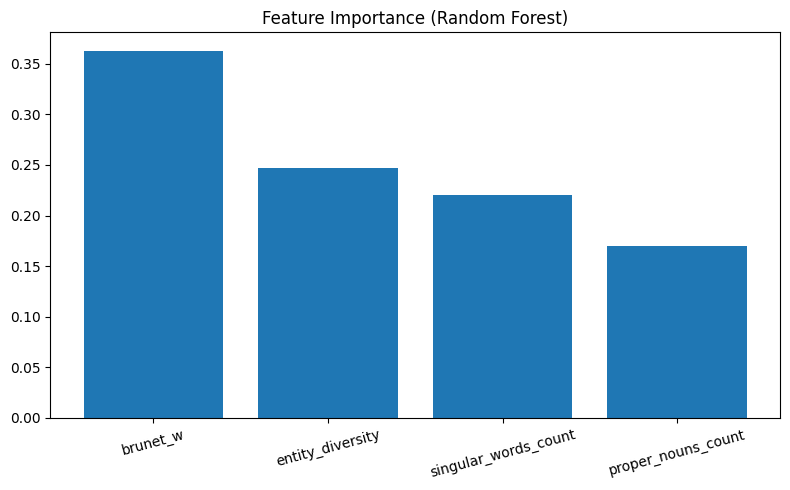

In [2]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = X.columns
importances = model.feature_importances_

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=15)
plt.tight_layout()
plt.show()

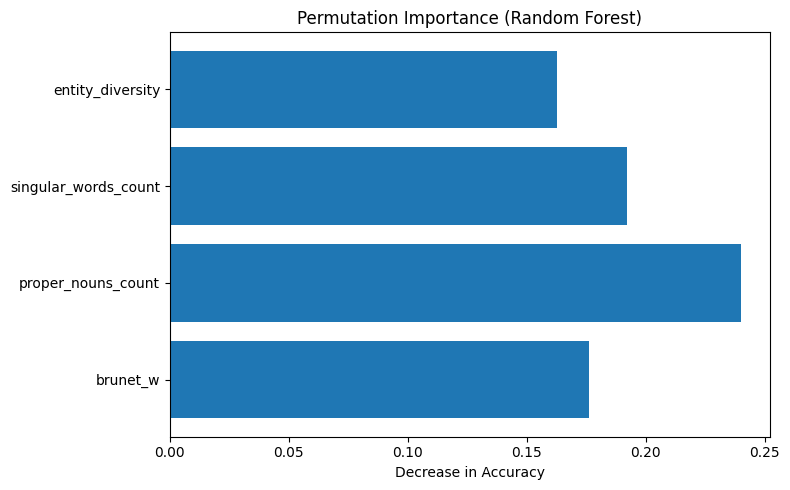

In [3]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model, X, y, n_repeats=10, random_state=42
)

perm_importance = result.importances_mean

plt.figure(figsize=(8,5))
plt.barh(feature_names, perm_importance)
plt.title("Permutation Importance (Random Forest)")
plt.xlabel("Decrease in Accuracy")
plt.tight_layout()
plt.show()